[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aims-foundations/torch_measure/blob/main/tutorials/doubly_robust_sparse_benchmarks.ipynb)

# DoublyRobustModel for Sparse Benchmarks

When benchmark response matrices have informative missingness (MNAR), a standard IRT fit is biased.
`DoublyRobustModel` wraps a fitted base model and learns a residual correction trained with
inverse-propensity-weighted loss to correct for the observation bias.

## Setup

In [1]:
import sys
import types

# Mock sentence_transformers to avoid import deadlock on macOS
sys.modules.setdefault("sentence_transformers", types.ModuleType("sentence_transformers"))
if not hasattr(sys.modules["sentence_transformers"], "SentenceTransformer"):
    sys.modules["sentence_transformers"].SentenceTransformer = object

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import torch  # noqa: E402

from torch_measure.models import DoublyRobustModel, Rasch  # noqa: E402
from torch_measure.models._predictor import predict_dense  # noqa: E402

# !pip install torch_measure  # uncomment if running on Colab

plt.rcParams["figure.dpi"] = 110
torch.manual_seed(42);

## Data

We generate a complete Rasch response matrix, then apply MNAR missingness: high-ability
models are less likely observed on easy items (frontier models skip trivial benchmarks).

In [2]:
n_models, n_items = 40, 50

ability = torch.randn(n_models) * 1.5
difficulty = torch.randn(n_items) * 1.5
logits = ability.unsqueeze(1) - difficulty.unsqueeze(0)
data_full = torch.bernoulli(torch.sigmoid(logits))

# MNAR: P(observed) depends on ability and difficulty
obs_logits = -1.2 * ability.unsqueeze(1) + 1.2 * difficulty.unsqueeze(0)
obs_probs = torch.sigmoid(obs_logits).clamp(0.08, 0.75)
obs_mask = torch.bernoulli(obs_probs).bool()
for i in range(n_models):
    if not obs_mask[i].any():
        obs_mask[i, 0] = True

data_sparse = data_full.clone()
data_sparse[~obs_mask] = float("nan")

print(f"{n_models} models x {n_items} items, {obs_mask.float().mean():.0%} observed")

40 models x 50 items, 48% observed


## Base Model

Fit a standard Rasch model on the sparse data. The MNAR pattern biases the ability estimates.

In [3]:
base = Rasch(n_subjects=n_models, n_items=n_items)
base.fit(data_sparse, max_epochs=200, verbose=False)

base_preds = predict_dense(base).detach()
base_mse = ((base_preds - data_full) ** 2).mean().item()
print(f"Base MSE on full matrix: {base_mse:.4f}")

Base MSE on full matrix: 0.1703


## DR Correction

Wrap the base in `DoublyRobustModel` and fit the correction layer.

In [4]:
dr = DoublyRobustModel(base, clip_propensity=(0.05, 0.95))
dr.fit(data_sparse, max_epochs=200, verbose=False)

dr_preds = predict_dense(dr).detach()
dr_mse = ((dr_preds - data_full) ** 2).mean().item()
print(f"DR MSE on full matrix: {dr_mse:.4f}")
print(f"Improvement: {(base_mse - dr_mse) / base_mse:.1%}")

DR MSE on full matrix: 0.1448
Improvement: 14.9%


## Results

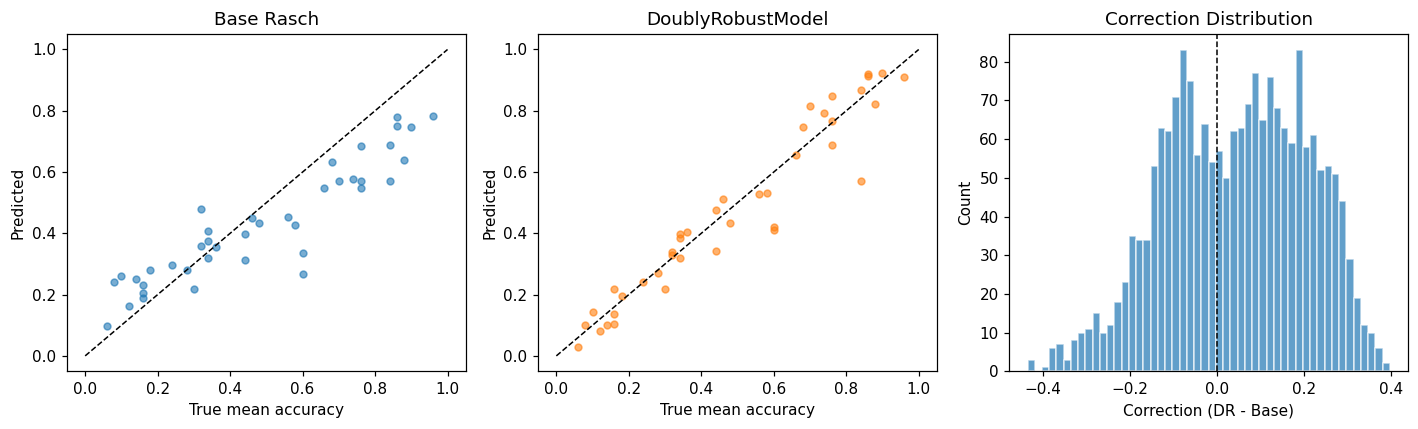

Mean abs bias: Base 0.1103, DR 0.0562


In [5]:
true_mean = data_full.mean(dim=1).numpy()
base_mean = base_preds.mean(dim=1).numpy()
dr_mean = dr_preds.mean(dim=1).numpy()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].scatter(true_mean, base_mean, alpha=0.6, s=20)
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_xlabel("True mean accuracy")
axes[0].set_ylabel("Predicted")
axes[0].set_title("Base Rasch")

axes[1].scatter(true_mean, dr_mean, alpha=0.6, s=20, color="tab:orange")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("True mean accuracy")
axes[1].set_ylabel("Predicted")
axes[1].set_title("DoublyRobustModel")

correction = (dr_preds - base_preds).numpy().ravel()
axes[2].hist(correction, bins=50, edgecolor="white", alpha=0.7)
axes[2].axvline(0, color="k", linestyle="--", lw=1)
axes[2].set_xlabel("Correction (DR - Base)")
axes[2].set_ylabel("Count")
axes[2].set_title("Correction Distribution")

plt.tight_layout()
plt.show()

print(f"Mean abs bias: Base {np.abs(base_mean - true_mean).mean():.4f}, DR {np.abs(dr_mean - true_mean).mean():.4f}")

See `torch_measure.models.DoublyRobustModel` for the full API.